In [7]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [8]:
torch.backends.mkldnn.enabled = True

In [9]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [10]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [11]:
model4_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model4_0)
describe(model4_0)

MACs: 5.45 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16,

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loading checkpoint from model_weights/model4_0.pt
Starting
Epoch 1/60: Train loss = 1.1873, Train accuracy = 0.5754, Test loss = 1.2053, Test accuracy = 0.5723
Epoch 2/60: Train loss = 0.9096, Train accuracy = 0.6712, Test loss = 0.8906, Test accuracy = 0.6807
Epoch 3/60: Train loss = 0.8100, Train accuracy = 0.7140, Test loss = 0.7822, Test accuracy = 0.7249
Epoch 4/60: Train loss = 0.7149, Train accuracy = 0.7506, Test loss = 0.7177, Test accuracy = 0.7488
Epoch 5/60: Train loss = 0.7140, Train accuracy = 0.7506, Test loss = 0.7187, Test accuracy = 0.7515
Epoch 6/60: Train loss = 0.6380, Train accuracy = 0.7774, Test loss = 0.6472, Test accuracy = 0.7782
Epoch 7/60: Train loss = 0.6896, Train accuracy = 0.7605, Test loss = 0.7052, Test accuracy = 0.7617
Epoch 8/60: Train loss = 0.6342, Train accuracy = 0.7790, Test loss = 0.6592, Test accuracy = 0.7748
Epoch 9/60: Train loss = 0.6086, Train accuracy = 0.7901, Test loss = 0.6412, Test accuracy = 0.7841
Epoch 10/60: Train loss = 0.5480

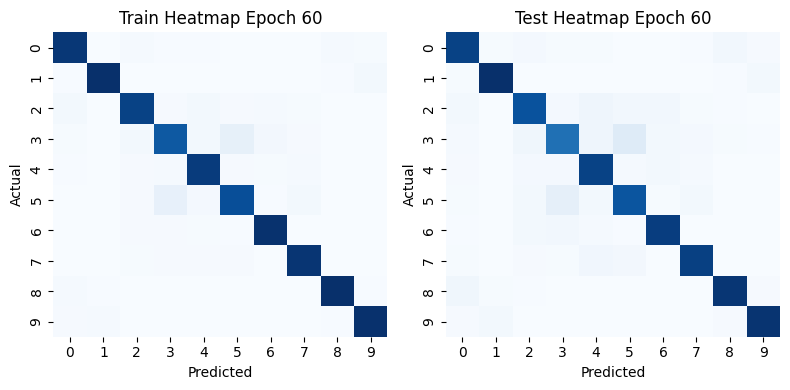

<Figure size 1200x600 with 0 Axes>

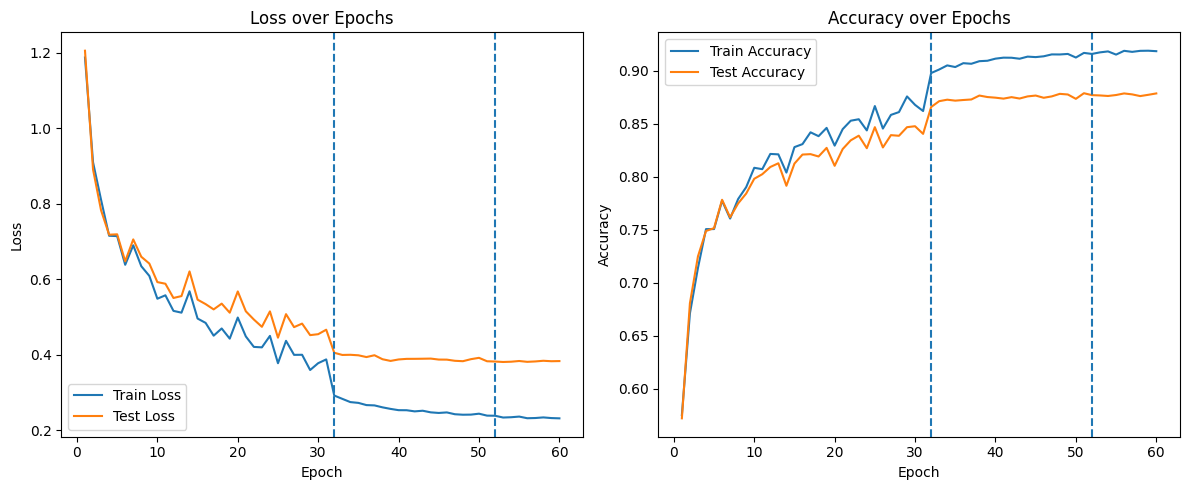

In [12]:
trainf32(model4_0,"model_weights/model4_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [13]:
model4_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model4_1)
describe(model4_1)

MACs: 5.45 MMac, Params: 56.07 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-10              [1, 30, 16,

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loading checkpoint from model_weights/model4_1.pt
Starting
Epoch 1/60: Train loss = 1.0612, Train accuracy = 0.6311, Test loss = 1.0550, Test accuracy = 0.6375
Epoch 2/60: Train loss = 0.8271, Train accuracy = 0.7118, Test loss = 0.8403, Test accuracy = 0.7155
Epoch 3/60: Train loss = 0.7106, Train accuracy = 0.7525, Test loss = 0.7127, Test accuracy = 0.7515
Epoch 4/60: Train loss = 0.7458, Train accuracy = 0.7421, Test loss = 0.7713, Test accuracy = 0.7386
Epoch 5/60: Train loss = 0.6257, Train accuracy = 0.7786, Test loss = 0.6553, Test accuracy = 0.7744
Epoch 6/60: Train loss = 0.5897, Train accuracy = 0.7939, Test loss = 0.6102, Test accuracy = 0.7861
Epoch 7/60: Train loss = 0.5697, Train accuracy = 0.8024, Test loss = 0.6058, Test accuracy = 0.7907
Epoch 8/60: Train loss = 0.5686, Train accuracy = 0.7992, Test loss = 0.6086, Test accuracy = 0.7907
Epoch 9/60: Train loss = 0.5235, Train accuracy = 0.8189, Test loss = 0.5485, Test accuracy = 0.8123
Epoch 10/60: Train loss = 0.5163

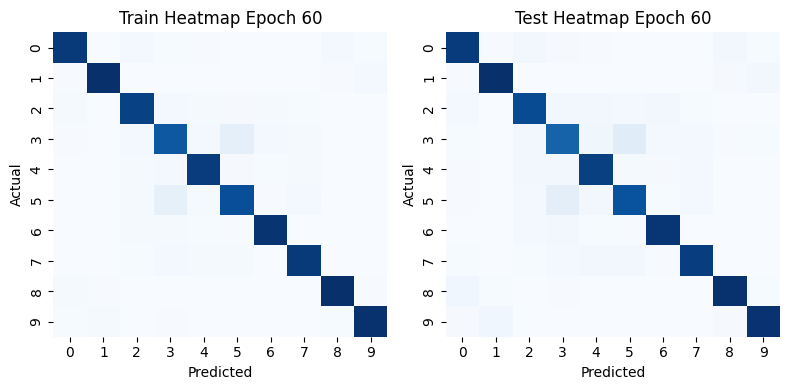

<Figure size 1200x600 with 0 Axes>

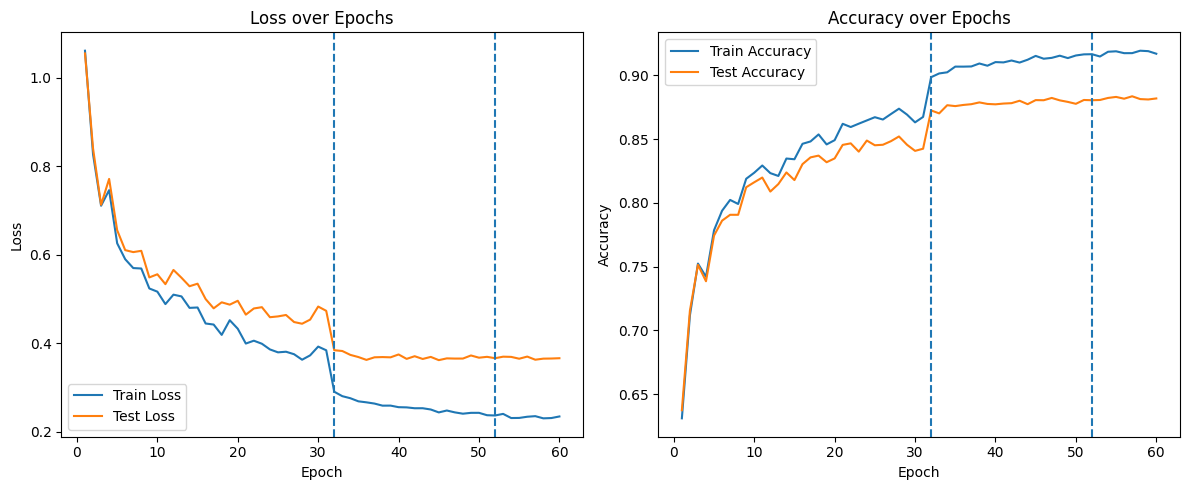

In [14]:
trainf32(model4_1,"model_weights/model4_1.pt",criterion,train_dataset,val_dataset, batch_size=64)